# 同預算事件驅動容量實驗

目標是在 **相同 720 worker-minutes 上限** 下，比較固定 12、定時 8/24、反應式、事件驅動與知道真實尖峰時間的參考組。這是合成實驗；不能直接證明真實券商環境也會獲勝。

In [1]:
from dataclasses import asdict, replace
import itertools
import pandas as pd
import matplotlib.pyplot as plt

from openingguard.budget_experiment import (
    STRATEGIES, fixture_decision, generate_truth, load_config, make_cases,
    openai_decision, paired_interval, run_cases, simulate, wilson_interval,
)

config = load_config()
pd.Series(config, name="value").to_frame().head(20)

,value
version,event-budget-v3-hybrid-agent-reactive
synthetic_assumption,True
horizon_seconds,3600
dt_seconds,0.1
arrival_guard_seconds,2
base_workers,8
fixed_workers,12
burst_workers,24
budget_worker_minutes,720
concurrency_slots,20


## 執行開關與資料切分

目前 `RUN_EXPERIMENTS=True`，可重新產生 100-run 主實驗與 Agent 解救次數；敏感度與付費 OpenAI API 維持關閉。調參只准使用 `tuning_seeds`；報告數字使用另一組固定 held-out seeds。

In [2]:
RUN_EXPERIMENTS = True
RUN_SENSITIVITY = False
RUN_LLM = False

tuning_seeds = config["tuning_seeds"]
evaluation_seeds = list(range(
    config["evaluation_seed_start"],
    config["evaluation_seed_start"] + config["evaluation_runs"],
))
assert set(tuning_seeds).isdisjoint(evaluation_seeds)
len(tuning_seeds), len(evaluation_seeds)

(5, 100)

## 單次路徑檢查

先檢查一個 `early_signal` 案例。所有策略使用同一條已生成的真實流量；Agent 的輸入不會改變流量。`fixture_NOT_LLM` 只測試事件進入政策後的機制。

In [3]:
cases = dict((truth.case_id, (truth, decision)) for truth, decision in make_cases(config))
truth, decision = cases["early_signal"]
arrivals, peak = generate_truth(config, truth, evaluation_seeds[0])
one_run = [
    simulate(config, truth, arrivals, peak, strategy,
             decision if strategy == "event" else None, keep_series=True)
    for strategy in STRATEGIES
]
pd.DataFrame([{k: v for k, v in row.items() if k != "series"} for row in one_run])[
    ["strategy", "accepted_within_slo_rate", "worker_minutes", "max_queue",
     "normal_idle_worker_equivalent_minutes", "ready_lead_seconds", "decision_source",
     "first_scale_trigger", "event_signal_applied", "queue_fallback_trigger_count"]
]

,strategy,accepted_within_slo_rate,worker_minutes,max_queue,normal_idle_worker_equivalent_minutes,ready_lead_seconds,decision_source,first_scale_trigger,event_signal_applied,queue_fallback_trigger_count
0,fixed12,0.569093,720.0,12000,285.668333,NaN,not_applicable,none,False,0
1,scheduled,1.000000,718.0,350,134.120000,0.0,not_applicable,scheduled,False,0
2,reactive,0.963900,706.0,12000,134.120000,-45.0,not_applicable,queue_reactive,False,0
3,event,1.000000,718.0,350,134.120000,0.0,fixture_NOT_LLM,event_signal,True,0
4,perfect_timing,1.000000,718.0,350,134.120000,0.0,not_applicable,perfect_timing,False,0


## Held-out Monte Carlo 主實驗

案例包含正常日、正確早期訊號、非固定時段尖峰、誤報、漏報、晚到訊號、過長尖峰與下游 1,200 RPS 硬上限。每個 seed 對所有策略共用同一條到達 trace，避免抽樣不公平。

In [4]:
results = pd.DataFrame()
if RUN_EXPERIMENTS:
    results = pd.DataFrame(run_cases(config, evaluation_seeds))
    print(f"完成 {len(results):,} 個 strategy-runs")
else:
    print("尚未執行：將 RUN_EXPERIMENTS 改為 True 後再跑。")

完成 4,000 個 strategy-runs


## 主指標與信賴區間

正式主指標是原始訂單在 2 秒 SLO 內被接受的比例；drop、逾時與觀察期末尚未完成都算失敗。另以 day/run 為統計單位，呈現壞日機率的 Wilson 95% 信賴區間。

In [5]:
summary = pd.DataFrame()
if not results.empty:
    rows = []
    for (case_id, strategy), group in results.groupby(["case_id", "strategy"]):
        bad = int(group["bad_run"].sum())
        low, high = wilson_interval(bad, len(group))
        rows.append({
            "case_id": case_id,
            "strategy": strategy,
            "mean_slo_success": group["accepted_within_slo_rate"].mean(),
            "bad_run_probability": bad / len(group),
            "bad_run_ci95_low": low,
            "bad_run_ci95_high": high,
            "mean_worker_minutes": group["worker_minutes"].mean(),
            "mean_normal_idle": group["normal_idle_worker_equivalent_minutes"].mean(),
        })
    summary = pd.DataFrame(rows)
summary

,case_id,strategy,mean_slo_success,bad_run_probability,bad_run_ci95_low,bad_run_ci95_high,mean_worker_minutes,mean_normal_idle
0,downstream_limit,event,0.573929,1.0,9.630065e-01,1.000000,720.000000,123.588554
1,downstream_limit,fixed12,0.568971,1.0,9.630065e-01,1.000000,720.000000,275.583490
2,downstream_limit,perfect_timing,0.573929,1.0,9.630065e-01,1.000000,720.000000,123.588554
3,downstream_limit,reactive,0.569365,1.0,9.630065e-01,1.000000,712.300000,126.048554
4,downstream_limit,scheduled,0.573929,1.0,9.630065e-01,1.000000,720.000000,123.588554
5,early_signal,event,1.000000,0.0,3.469447e-18,0.036993,718.460000,124.032192
6,early_signal,fixed12,0.568971,1.0,9.630065e-01,1.000000,720.000000,275.583490
7,early_signal,perfect_timing,1.000000,0.0,3.469447e-18,0.036993,718.460000,124.032192
8,early_signal,reactive,0.961802,1.0,9.630065e-01,1.000000,709.220000,125.412192
9,early_signal,scheduled,1.000000,0.0,3.469447e-18,0.036993,718.460000,124.032192


## 同一天的配對比較

以相同 case、相同 seed 相減，分別估計事件驅動相對固定 12、固定時段與反應式策略的 SLO 成功率差。信賴區間對 day-level 配對差做 bootstrap，不能把數百萬筆訂單誤當獨立樣本。

In [6]:
paired = pd.DataFrame()
if not results.empty:
    wide = results.pivot(index=["case_id", "seed"], columns="strategy",
                         values="accepted_within_slo_rate").reset_index()
    paired_rows = []
    for case_id, group in wide.groupby("case_id"):
        for comparator in ("fixed12", "scheduled", "reactive"):
            estimate = paired_interval(group["event"] - group[comparator])
            paired_rows.append({"case_id": case_id, "comparator": comparator, **estimate})
    paired = pd.DataFrame(paired_rows)
paired

,case_id,comparator,mean,ci95_low,ci95_high,n
0,downstream_limit,fixed12,0.004958,0.004574,0.005387,100
1,downstream_limit,scheduled,0.000000,0.000000,0.000000,100
2,downstream_limit,reactive,0.004565,0.004088,0.005082,100
3,early_signal,fixed12,0.431029,0.430863,0.431192,100
4,early_signal,scheduled,0.000000,0.000000,0.000000,100
5,early_signal,reactive,0.038198,0.037397,0.039110,100
6,false_alarm,fixed12,0.000000,0.000000,0.000000,100
7,false_alarm,scheduled,0.000000,0.000000,0.000000,100
8,false_alarm,reactive,0.000000,0.000000,0.000000,100
9,late_signal,fixed12,0.395799,0.395008,0.396468,100


## Agent 介入與成功解救次數

`Agent 介入` 表示事件訊號實際觸發預熱；`成功解救` 採更嚴格的配對定義：同一 case、同一 seed 下，Event 策略不是壞日，但 Reactive 或 Scheduled 是壞日。只介入但最後仍是壞日會另外計數。`fixture_NOT_LLM` 的結果只能稱為事件訊號機制，不是 OpenAI Agent 準確率。

In [7]:
rescue_summary = pd.DataFrame()
rescue_by_case = pd.DataFrame()
if not results.empty:
    bad = results.pivot(index=["case_id", "seed"], columns="strategy", values="bad_run")
    event_audit = (results[results["strategy"] == "event"]
                   .set_index(["case_id", "seed"])[["event_signal_applied", "queue_fallback_trigger_count"]])
    audit = bad.join(event_audit)
    audit["agent_intervened"] = audit["event_signal_applied"].astype(bool)
    audit["intervention_passed_slo"] = audit["agent_intervened"] & ~audit["event"]
    audit["rescued_vs_reactive"] = audit["intervention_passed_slo"] & audit["reactive"]
    audit["rescued_vs_scheduled"] = audit["intervention_passed_slo"] & audit["scheduled"]
    audit["intervened_but_failed"] = audit["agent_intervened"] & audit["event"]
    audit["queue_fallback_used"] = audit["queue_fallback_trigger_count"] > 0
    audit["false_alarm_intervention"] = audit["agent_intervened"] & (audit.index.get_level_values("case_id") == "false_alarm")
    metric_columns = ["agent_intervened", "intervention_passed_slo",
                      "rescued_vs_reactive", "rescued_vs_scheduled",
                      "intervened_but_failed", "queue_fallback_used",
                      "false_alarm_intervention"]
    rescue_summary = pd.DataFrame({
        "metric": metric_columns,
        "count": [int(audit[column].sum()) for column in metric_columns],
    })
    rescue_by_case = (audit.groupby(level="case_id")[metric_columns]
                      .sum().astype(int).reset_index())
display(rescue_summary)
display(rescue_by_case)

,metric,count
0,agent_intervened,600
1,intervention_passed_slo,300
2,rescued_vs_reactive,200
3,rescued_vs_scheduled,100
4,intervened_but_failed,300
5,queue_fallback_used,100
6,false_alarm_intervention,100


,case_id,agent_intervened,intervention_passed_slo,rescued_vs_reactive,rescued_vs_scheduled,intervened_but_failed,queue_fallback_used,false_alarm_intervention
0,downstream_limit,100,0,0,0,100,0,0
1,early_signal,100,100,100,0,0,0,0
2,false_alarm,100,100,0,0,0,0,100
3,late_signal,100,0,0,0,100,0,0
4,long_peak,100,0,0,0,100,0,0
5,missed_signal,0,0,0,0,0,100,0
6,normal,0,0,0,0,0,0,0
7,off_schedule,100,100,100,100,0,0,0


## 容量、Queue 與流量時間圖

這張圖同時呈現擴容與縮容。事件策略不會在需求剛下降時直接從 24 降到 8：必須先通過 minimum hold 與連續低負載確認，再降到 20-worker warm pool；暖備期沒有反彈才回到 8。若流量回升，20 workers 先承接服務，額外 4 workers 重新 warmup。100 ms 到達率只適合看瞬時波動，因此圖中使用 5 秒 rolling mean。

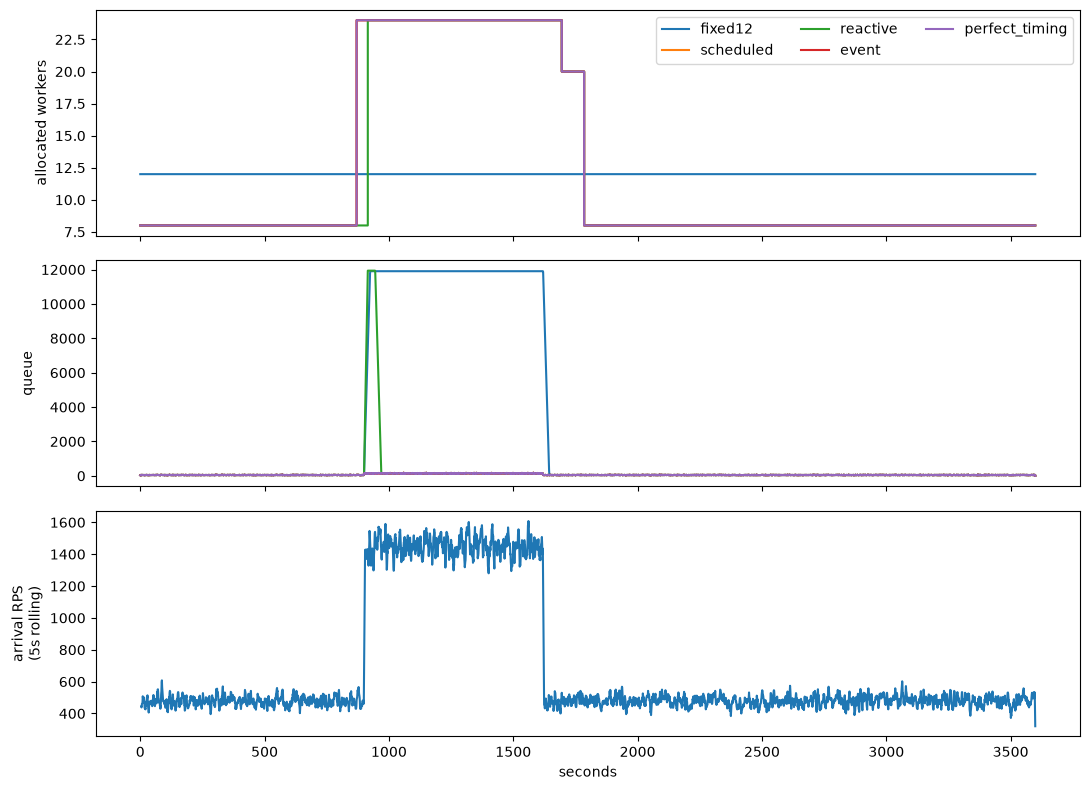

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for row in one_run:
    series = pd.DataFrame(row["series"])
    axes[0].plot(series["seconds"], series["allocated_workers"], drawstyle="steps-post", label=row["strategy"])
    axes[1].plot(series["seconds"], series["queue"], label=row["strategy"])
base_series = pd.DataFrame(one_run[0]["series"])
axes[2].plot(base_series["seconds"], base_series["arrivals_rps_100ms"].rolling(5).mean())
axes[0].set_ylabel("allocated workers")
axes[1].set_ylabel("queue")
axes[2].set_ylabel("arrival RPS\n(5s rolling)")
axes[2].set_xlabel("seconds")
axes[0].legend(ncol=3)
plt.tight_layout()

## 尖峰強度、長度與訊號 lead time 敏感度

這不是主 Demo，而是可信度證據。每次只改一組參數，仍用 held-out seeds；不能挑選對事件驅動策略最有利的格子當結論。

In [9]:
sensitivity = pd.DataFrame()
if RUN_SENSITIVITY:
    rows = []
    original_truth, original_decision = cases["early_signal"]
    for peak_rps, duration, lead in itertools.product(
        config["sensitivity_peak_rps"],
        config["sensitivity_peak_durations"],
        config["sensitivity_signal_leads"],
    ):
        truth = replace(original_truth, case_id=f"r{peak_rps}_d{duration}_l{lead}",
                        peak_rps=peak_rps, peak_duration=duration)
        event = replace(original_decision.event,
                        published_at=max(0, truth.peak_start - lead - 20),
                        available_at=max(0, truth.peak_start - lead),
                        expected_start=truth.peak_start)
        decision = fixture_decision(config, event)
        grid = run_cases(config, evaluation_seeds, [(truth, decision)])
        rows.extend({**row, "peak_rps": peak_rps, "duration": duration, "lead": lead}
                    for row in grid)
    sensitivity = pd.DataFrame(rows)
sensitivity.head()

""


## 真正 OpenAI Agent 的可選入口

這段只把時間戳已公開事件與人工標註 few-shot 範例送給單次 OpenAI Agent，沒有未來 RPS 或模擬真值。預設不執行；評審展示不能把 fixture 當成 LLM 成績。工具呼叫採固定 schema，模型只能選 `risk_id` 與 `severity`，容量數字仍由版本化設定決定。

In [10]:
llm_decision = None
if RUN_LLM:
    _, fixture = cases["early_signal"]
    llm_decision = openai_decision(config, fixture.event)
    print(asdict(llm_decision))
else:
    print("尚未呼叫 OpenAI API；執行此區塊需要 OPENAI_API_KEY。")

尚未呼叫 OpenAI API；執行此區塊需要 OPENAI_API_KEY。


## 可以與不可以宣稱的結論

只有在實際跑完 held-out 實驗且信賴區間支持時，才能說「在本合成假設與相同資源上限下，事件驅動策略改善 SLO」。固定時段策略是必要的強基準。即使結果較好，也不能宣稱已預測真實券商事故；14 筆公開事故目前只能用於回顧式 Agent 分類，尚未形成帶時間戳的前瞻資料集。